# Q11. Grouped Statistics with Pandas groupby

In [ ]:
# Q11. Grouped Statistics with Pandas groupby


# Create a DataFrame with 300 rows: 'city' (random choice from ['Lagos','Douala','Nairobi','Accra']),
# 'income' (lognormal by city — each city has a different mu), 'age' (uniform 22 to 60). Use
# df.groupby('city')['income'].agg(['mean','median','std','count']) to create a summary table. Then plot a
# seaborn barplot showing the median income per city with error bars.
# Notice how groupby + agg gives you a full statistical profile for every subgroup in one line — a
# workflow you will use on every real dataset.
# � Hint: For the lognormal by city, use np.where or dict-based mapping: df['income'] = df['city'].map({'Lagos': ...,
# ...}). Then add noise.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(3)
n=300
cities=np.random.choice(['Lagos', 'Douala', 'Nairobi', 'Accra'], n)
cities

array(['Nairobi', 'Lagos', 'Douala', 'Accra', 'Lagos', 'Lagos', 'Lagos',
       'Douala', 'Douala', 'Accra', 'Nairobi', 'Accra', 'Douala',
       'Douala', 'Nairobi', 'Douala', 'Accra', 'Nairobi', 'Lagos',
       'Lagos', 'Lagos', 'Douala', 'Accra', 'Nairobi', 'Lagos', 'Nairobi',
       'Douala', 'Nairobi', 'Nairobi', 'Nairobi', 'Nairobi', 'Accra',
       'Lagos', 'Douala', 'Accra', 'Nairobi', 'Douala', 'Lagos',
       'Nairobi', 'Douala', 'Douala', 'Nairobi', 'Lagos', 'Accra',
       'Nairobi', 'Accra', 'Lagos', 'Accra', 'Douala', 'Accra', 'Accra',
       'Lagos', 'Douala', 'Lagos', 'Nairobi', 'Douala', 'Douala', 'Accra',
       'Nairobi', 'Lagos', 'Lagos', 'Accra', 'Nairobi', 'Lagos', 'Lagos',
       'Douala', 'Nairobi', 'Lagos', 'Accra', 'Douala', 'Lagos', 'Lagos',
       'Accra', 'Douala', 'Douala', 'Nairobi', 'Douala', 'Douala',
       'Douala', 'Douala', 'Douala', 'Accra', 'Nairobi', 'Accra', 'Lagos',
       'Lagos', 'Accra', 'Accra', 'Lagos', 'Accra', 'Lagos', 'Lagos',
       'L

             mean   median      std  count
city                                      
Accra     36833.0  32365.0  21723.0     67
Douala    66122.0  51210.0  55713.0     72
Lagos    124306.0  96154.0  89181.0    101
Nairobi   65558.0  48412.0  45742.0     60


AttributeError: Rectangle.set() got an unexpected keyword argument 'pallete'

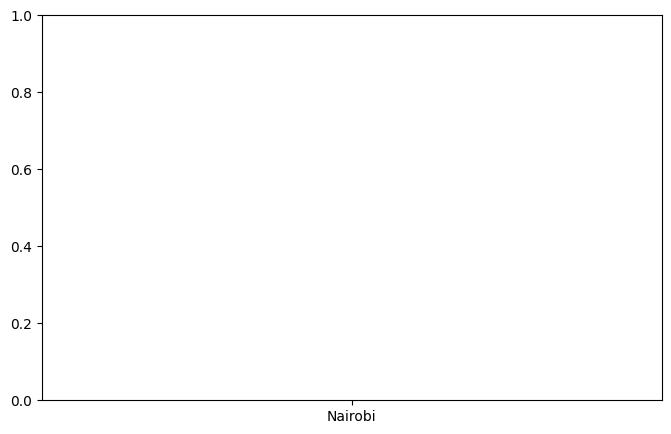

In [19]:
# assign  different income levels per city using lookup dict
mu_map={'Lagos':11.5, 'Douala':10.8, 'Nairobi':11.0, 'Accra':10.5}
income=np.array([
    np.random.lognormal(mu_map[c], 0.7) for c in cities
])
df=pd.DataFrame({
    'city':cities,
    'income':income,
    'age':np.random.uniform(22, 60, n)
})
summary=df.groupby('city')['income'].agg(['mean', 'median','std', 'count'])
print(summary.round(0))
summary
fig, ax = plt.subplots(figsize=(8, 5))
# estimator='median' tells seaborn to plot the median bar
sns.barplot(data=df, x='city', y='income', estimator='median', pallete='Set2', ax=ax, errorbar='sd')
ax.set_title('Median Income by City (error bars = 1 SD)')
ax.set_ylabel('Income')
plt.tight_layout()
plt.show()